In [16]:
import trackpy as tp
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
from PIL import Image
import glob

UPLOADING DATA

In [17]:


Paths = glob.glob('Tracks/20230626/*.csv')    # Write Path to the folder in which your tracks are saved. Example : Data are saved in folder 20230626 ---> PATH_to_20230626/* 
print(Paths)

# Ordering of the tracks 

Tracks = []

for path in Paths:
    Tracks.append(pd.read_csv(path))


Tracks[0]['particle'] = Tracks[0]['particle'].replace(np.unique(Tracks[0]['particle']), np.arange(0, len(np.unique(Tracks[0]['particle'])), 1))

max_ind_0 = 0 

for i in np.arange(1, len(Tracks) , 1) : 
    max_ind = max(np.arange(0, len(np.unique(Tracks[i-1]['particle'])), 1)) + max_ind_0
    Tracks[i]['particle'] = Tracks[i]['particle'].replace(np.unique(Tracks[i]['particle']), np.arange( max_ind + 1, max_ind + len(np.unique(Tracks[i]['particle'])) + 1, 1))
    max_ind_0 = max_ind + 1
    

par = []

for i in np.arange(0, len(Tracks) , 1): 
    par.append(np.unique(Tracks[i]['particle']))
    
print(par)



['Tracks/20230626/POPC_DSPEpeg20k_01pc_DOPEatto488_01pc_7_processed_tracks.csv', 'Tracks/20230626/POPC_DSPEpeg20k_01pc_DOPEatto488_01pc_2_processed_tracks.csv', 'Tracks/20230626/POPC_DSPEpeg20k_01pc_DOPEatto488_01pc_6_processed_tracks.csv', 'Tracks/20230626/POPC_DSPEpeg20k_01pc_DOPEatto488_01pc_0_processed_tracks.csv', 'Tracks/20230626/POPC_DSPEpeg20k_01pc_DOPEatto488_01pc_5_processed_tracks.csv', 'Tracks/20230626/POPC_DSPEpeg20k_01pc_DOPEatto488_01pc_1_processed_tracks.csv']
[array([0, 1, 2, 3, 4, 5, 6]), array([7, 8, 9]), array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19]), array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]), array([33, 34, 35, 36, 37, 38, 39]), array([40, 41, 42, 43, 44, 45, 46, 47])]


CREATE DATA FRAME TO ANALYSE

In [18]:

select =[]
for track in Tracks:
    for i in np.unique(track['particle']):
        select.append(track[track['particle'].isin([i])])



print(f'Number of tracks to analyze: {len(select)} Tracks')


Number of tracks to analyze: 48 Tracks


PLOTTING TRACKS

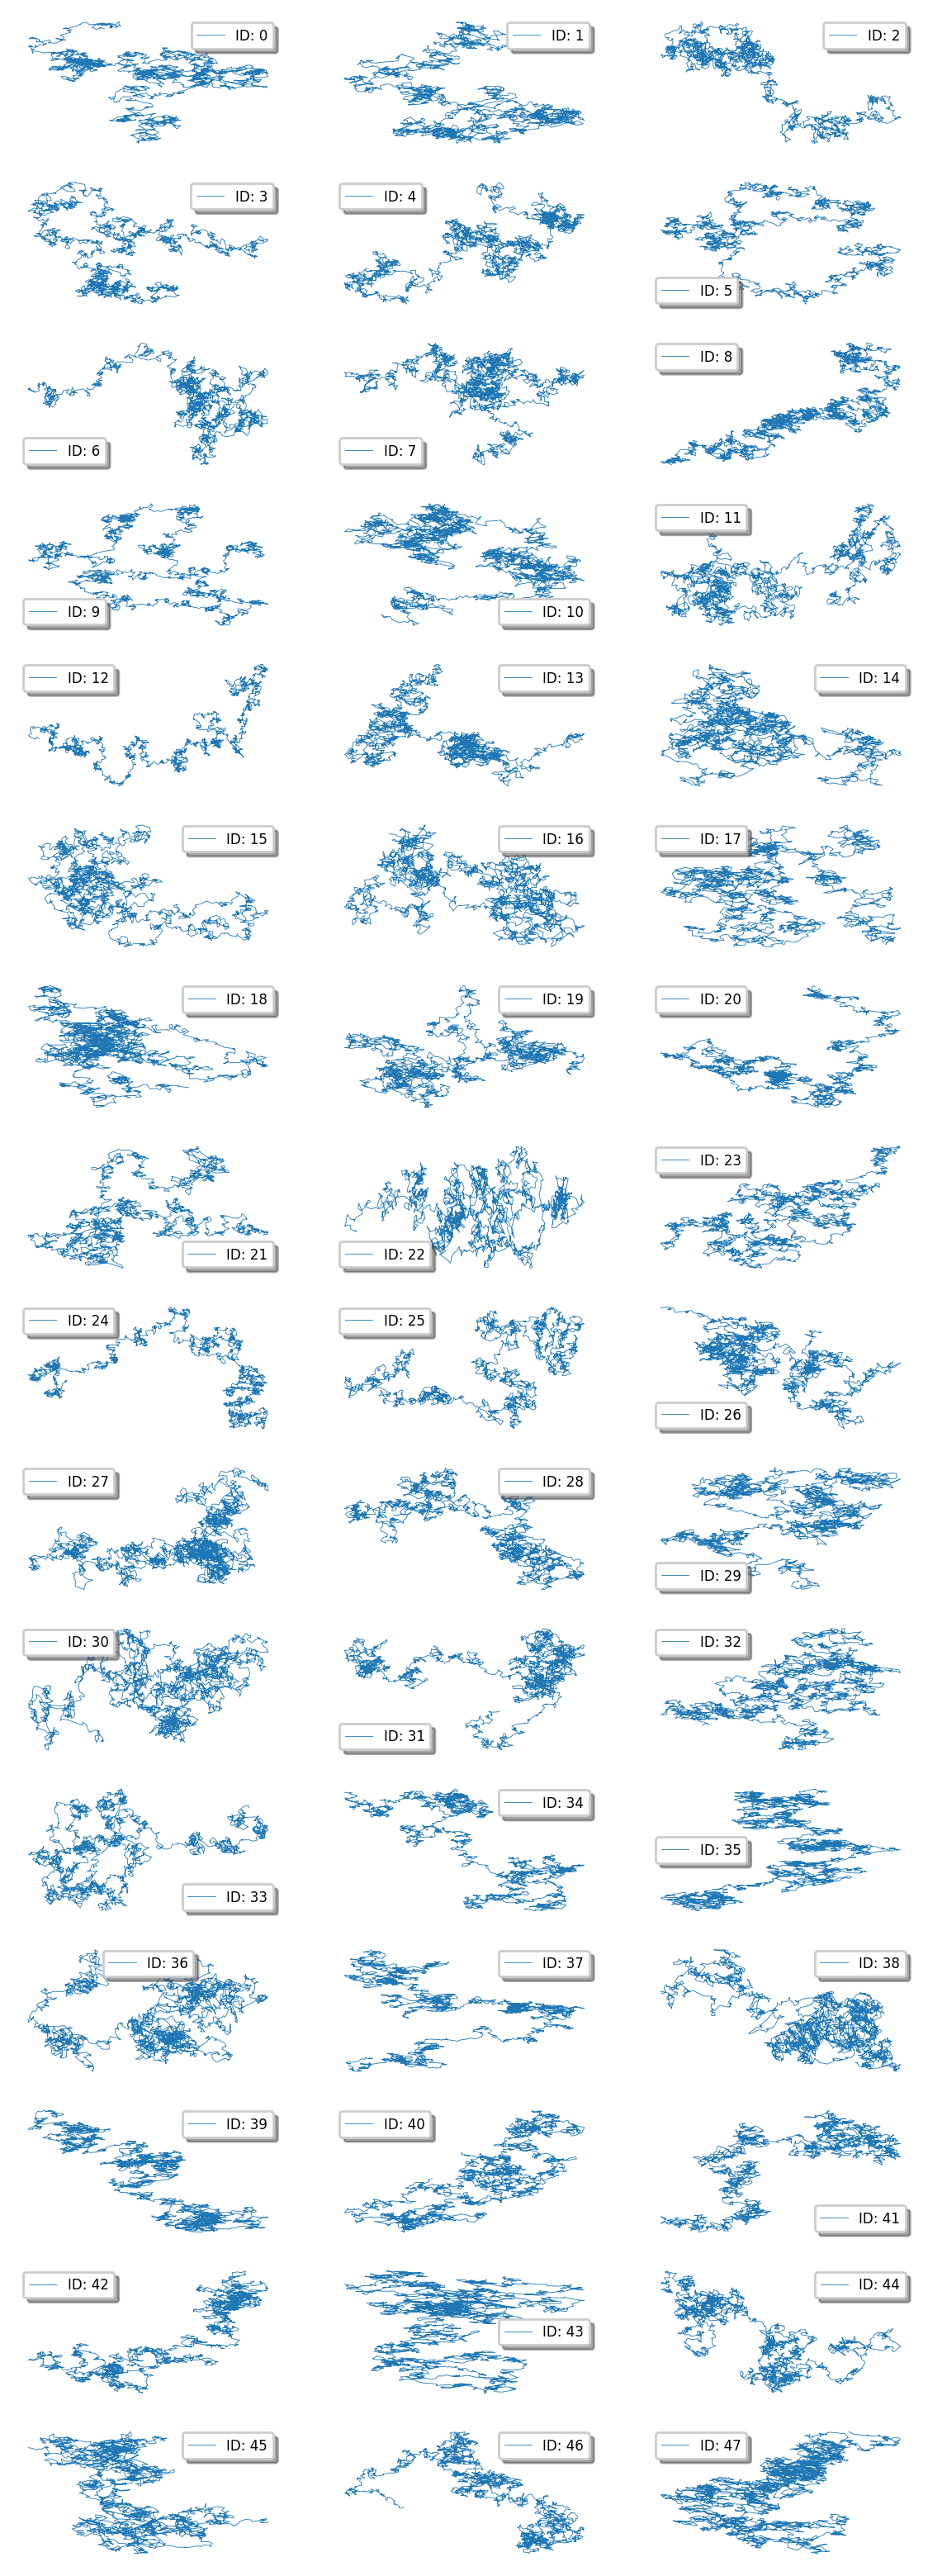

In [19]:

fig, ax = plt.subplots(len(select)//3, 3, figsize = (7,20), frameon = True, dpi= 200)

color = ['red', 'green', 'yellow', 'deepskyblue', 'm', 'orange', 'maroon','lime','purple', 'crimson', 'orchid']


for i in range(len(select)//3):
    for j in range(3):
        df = select[i*3 + j]
        ax[i,j].plot(df['x']/0.09 ,df['y']/0.09 ,linewidth = 0.3, label = f"ID: {i*3+j}") 
        ax[i,j].legend(loc = "best", fancybox = True, shadow=True, fontsize = 6)
        ax[i,j].axis('off')



MEAN SQUARED DISPLACEMENT

(0.0, 0.5)

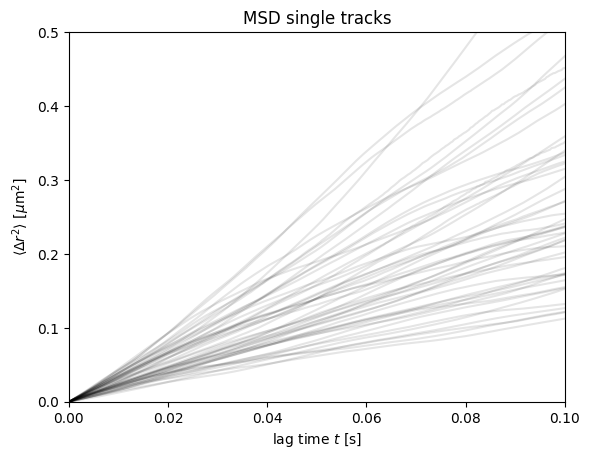

In [20]:

Track_merged = pd.concat(select)


im_msd = tp.imsd(Track_merged, mpp = 0.09 , fps = 3000 , max_lagtime = 3000)    # MSD calculated for each track, mpp : micron per pixel, fps : frame per second

std_dev = im_msd.iloc[: , 0:3000].std(axis=1)   # standard dev at each time point of the all MSD curves


#PLOTTING MSDs

fig, ax = plt.subplots()
ax.set_title('MSD single tracks')
ax.plot(im_msd.index, im_msd, 'k-', alpha=0.1) 
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$ [s]')
ax.set_xlim(0,0.1)
ax.set_ylim(0, 0.5)

ENSAMBLE MSD ANALYSIS

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/trackpy/motion.py:235: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  results = msds.mul(msds['N'], axis=0).mean(level=1)  # weighted average
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/trackpy/motion.py:236: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  results = results.div(msds['N'].mean(level=1), axis=0)  # weights normalized


[Text(0, 0.5, '$\\langle \\Delta r^2 \\rangle$ [$\\mu$m$^2$]'),
 Text(0.5, 0, 'lag time $t$ [s]')]

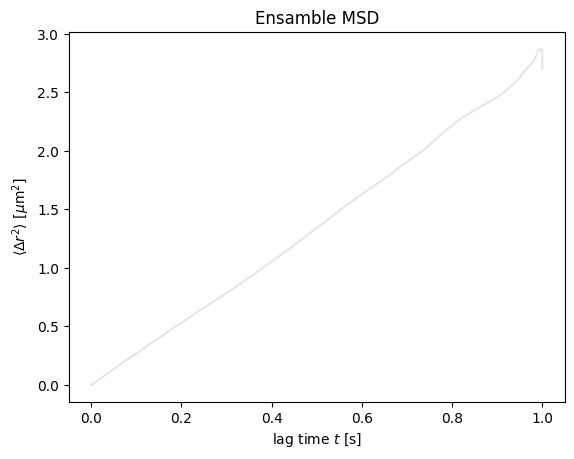

In [21]:

im_enmsd = tp.emsd(Track_merged, mpp = 0.09 , fps = 3000 , max_lagtime = 3000 )   # ensamble msd calculation 

# plotting 

fig, ax = plt.subplots()
ax.plot(im_enmsd.index, im_enmsd, 'k-', alpha=0.1)  # black lines, semitransparent
ax.set_title('Ensamble MSD')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$ [s]')


(0.0, 0.4)

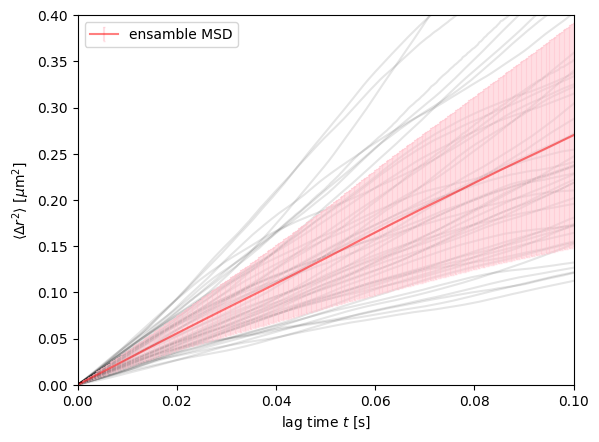

In [22]:
fig, ax = plt.subplots()

# PLOT OF SINGLE MSD CURVES + ENSAMBLE MSD + STD DEVIATION 
ax.plot(im_msd.index, im_msd, 'k-', alpha=0.1)
ax.errorbar(im_enmsd.index, im_enmsd, yerr=std_dev, ecolor = 'pink' , capsize = 1,alpha=0.5, color= 'r', label = 'ensamble MSD')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$ [s]')
ax.legend()
ax.set_xlim(0,0.1)
ax.set_ylim(0, 0.4)

DATA SELECTION FOR FITTING

In [23]:
n_frame = 300    # number of points we want to use for the linear fitting 

im_fit = im_enmsd.head(n_frame)    #10% of the all time acquisition 


FITTING

Diffusion coefficient: 0.677723472132717 +- 0.0003684135487290314 [um^2/s]
Dynamic localization: 18.88753136811546 +- 0.5636417184497103 [nm]


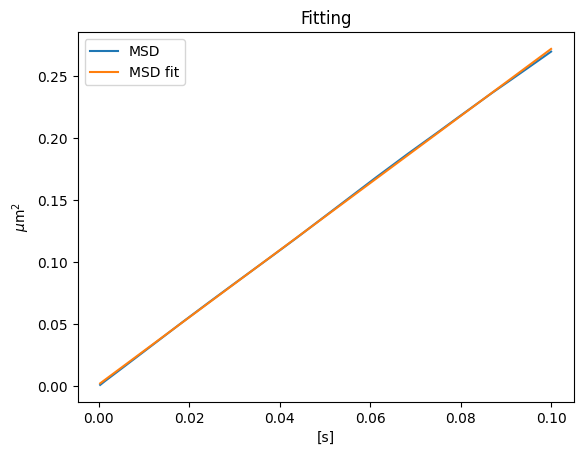

In [24]:
from scipy.optimize import curve_fit



exp_time = 0.0003 # [s] 300us         , exposure time 
frame_time = 0.000303 # [s] 303 us    , frame time 

t = im_fit.index      # time array

n = np.arange(1,n_frame+1,1)

R = (1/6)*(exp_time/frame_time)     # blurring correction factor 

# fitting function definition 

def MSD (t, D, d) :                
    dt = 0.000303 
    return 4*D*t*(1-((2*R)/(t/dt))) + 4*np.square(d) 

# fitting with the ensamble MSD

popt, pcov = curve_fit(MSD, t, im_fit )

# print results + plotting fitting

print(f"Diffusion coefficient: {popt[0]} +- {np.sqrt(pcov[0,0])} [um^2/s]\nDynamic localization: {popt[1]*1e3 } +- {np.sqrt(pcov[1,1])*1e3} [nm]")
plt.plot(t, im_fit, label = 'MSD')
plt.title('Fitting')
plt.plot(t, MSD(t, popt[0], popt[1]), label = 'MSD fit')
plt.ylabel(r'$\mu$m$^2$')
plt.xlabel('[s]')
plt.legend()


DIFFUSION COEFFICIENT OVER TIME

Text(0.5, 0, 'Lag time[s]')

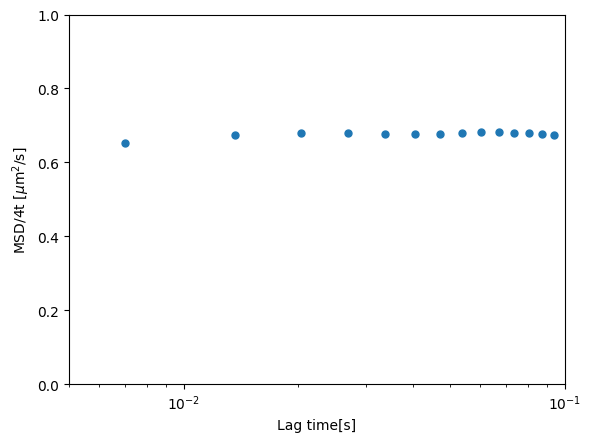

In [25]:
dt = 0.000303
stride = 20


plt.errorbar(t[::stride], (im_fit/(4*t*(1-((2*R)/(t/dt))))-(np.square(popt[1])/t*(1-((2*R)/(t/dt)))))[::stride],fmt='o',ms=5) 
plt.xscale('log')

plt.xlim(0.005, 0.1)
plt.ylim(0, 1)
plt.ylabel(r'MSD/4t [$\mu$m$^2$/s]')
plt.xlabel('Lag time[s]')
